# The code behind it: build the binomial & Poisson in NumPy

*Part 1 · Lesson 8 · the code behind it  ·  data: US Births 2014 · USGS earthquakes (same as Lesson 8)*

*↩ A companion to [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb).*

**↩ Back:** [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](08-binomial-poisson~another-dataset.ipynb)

**In Lesson 8 you trusted two formulas** — the Binomial $\binom{n}{k}p^k(1-p)^{n-k}$ and the Poisson
$e^{-\lambda}\lambda^k/k!$ — and watched `scipy.stats` draw them for you. This companion **opens the hood**:
you'll write both probability-mass functions *yourself*, straight from the math, and prove they match SciPy
to the last decimal. After that a "pmf" stops being a library call and becomes one short line of code you
understand.

Same data, same models, same final numbers — but the focus shifts from *what the distributions mean* to
**how you build them in Python**. We'll go in the order a programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load the births and the earthquakes, read $p$ and $\lambda$ off them.
3. **Build it step by step** — turn the two pmf formulas into NumPy, simulate, and check every probability against SciPy with `np.allclose`.
4. **The idiom** — vectorized simulation + `np.bincount` for an empirical pmf vs. a slow Python loop.
5. **Refactor into a function** — your two pmf functions are the reusable artifacts; reuse them for the Binomial→Poisson limit.
6. **Now you code** — predict-then-run exercises.
7. **What you learned** — the coding *and* the statistics.

You don't need Lesson 8 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have written two small functions — `binom_pmf(k, n, p)` and
`pois_pmf(k, lam)` — that return a probability *from the formula alone*, no library doing the work for you.
You'll simulate both processes with a random generator, pile the results into a histogram, and overlay your
formula on top to watch them agree. Then you'll reuse the very same two functions to see the famous
Binomial→Poisson limit. Nothing here needs new statistics; everything is the Python *underneath* the
`stats.binom.pmf` / `stats.poisson.pmf` calls from the core lesson.

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **NumPy** | fast math on whole arrays; a random generator | simulating draws, tallying counts, vectorized arithmetic |
| **`math`** | exact integer math from the standard library | `math.comb`, `math.factorial`, `math.exp` for the formulas |
| **SciPy** (`scipy.stats`) | ready-made distributions | the *answer key* we check our from-scratch pmfs against |
| **pandas / matplotlib** | tables and plotting | loading the CSVs, drawing the histograms |

A **pmf** (probability mass function) is just a rule: *give me a count $k$, I give you its probability.* That
is exactly what a Python function is, so building one is a perfect fit.

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import math
sl.use_course_style()
rng = np.random.default_rng(0)   # fixed seed -> the notebook runs the same every time

# Part A data: 1000 US births in 2014 (the binomial example).
births = sl.load_csv('births14.csv', url='https://www.openintro.org/data/csv/births14.csv')
print(f'Loaded a {type(births).__name__} with shape {births.shape}  (rows, columns)')
births[['weight', 'lowbirthweight', 'sex']].head()

Loaded a DataFrame with shape (1000, 13)  (rows, columns)


,weight,lowbirthweight,sex
0,6.96,not low,male
1,8.86,not low,female
2,7.51,not low,female
3,6.19,not low,male
4,6.75,not low,female


## 2) The data in code

The two models each need one number read off the data: the Binomial needs a success probability $p$, and
the Poisson needs a rate $\lambda$. A programmer pulls those out *before* touching any formula.

### The Binomial's $p$ — a proportion is the mean of a True/False column

"Success" here is a **low-birthweight** baby (under 2500 g). The `lowbirthweight` column is text, so we make
a boolean column `is_low` (`True`/`False`), and the single most useful pandas idiom — **the mean of a
True/False column is the proportion that are True** — hands us $p$ directly.

In [2]:
is_low = (births['lowbirthweight'] == 'low')   # a column of True/False
n_low  = int(is_low.sum())                      # True counts as 1
p      = is_low.mean()                          # mean of True/False = proportion True

print('is_low is a', type(is_low).__name__, 'of', len(is_low), 'True/False values; first 5:')
print(is_low.head().to_list())
print(f'\nlow-birthweight babies: {n_low} out of {len(births)}')
print(f'p = P(low birthweight) = {p:.3f}')

n = 30   # we will model a random group of 30 births, exactly as the core lesson did
print(f'\nWe will study X ~ Binomial(n={n}, p={p:.3f}).')

is_low is a Series of 1000 True/False values; first 5:
[False, False, False, False, False]

low-birthweight babies: 81 out of 1000
p = P(low birthweight) = 0.081

We will study X ~ Binomial(n=30, p=0.081).


### The Poisson's $\lambda$ — an average count per interval

For the Poisson we load every magnitude-4.5+ earthquake worldwide in June 2024, tally how many struck each
calendar day, and take the **mean per day**. That average *is* the rate $\lambda$. (We `reindex` onto all 30
June days so that any quiet day still counts as a row — though in this busy month every day had quakes.)

In [3]:
# Part B data: M4.5+ earthquakes worldwide, June 2024 (USGS), same file as the core lesson.
quakes = sl.load_csv(
    'earthquakes_2024_06.csv',
    url='https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv'
        '&starttime=2024-06-01&endtime=2024-07-01&minmagnitude=4.5&orderby=time-asc')
print(f'{len(quakes)} earthquakes (M4.5+) in June 2024')

# Build DAILY COUNTS: one number per calendar day in June.
day = pd.to_datetime(quakes['time']).dt.date
daily = day.value_counts().reindex(
    pd.date_range('2024-06-01', '2024-06-30').date, fill_value=0)

lam = daily.mean()   # the Poisson rate is just the average count per day
print(f'days observed = {len(daily)}')
print(f'mean per day  = {lam:.2f}   <- this is lambda')
print(f'variance/day  = {daily.var(ddof=1):.2f}   (Poisson fingerprint: mean ~ variance)')
print(f'busiest day   = {daily.max()} quakes')

507 earthquakes (M4.5+) in June 2024
days observed = 30
mean per day  = 16.90   <- this is lambda
variance/day  = 17.20   (Poisson fingerprint: mean ~ variance)
busiest day   = 28 quakes


## 3) Build it step by step

Now the heart of it. Each model is a one-line `scipy.stats` call *and* a short formula — we'll write the
formula ourselves and check the two agree across the **whole** range of counts. Once you've built it, the
library call is no longer a mystery box.

### The Binomial pmf, straight from the formula

$$P(X=k) = \binom{n}{k}\,p^{k}\,(1-p)^{\,n-k} \qquad\text{— pattern probability } p^k(1-p)^{n-k}\text{, times how many patterns } \binom{n}{k}.$$

In Python that is one line. `math.comb(n, k)` is exactly $\binom{n}{k}$ (the number of ways to choose $k$
successes out of $n$), and `**` is "to the power of". We write it, then check it against `stats.binom.pmf`
over **every** $k$ from 0 to $n$ at once with `np.allclose` — which is True only if all the probabilities
match to floating-point precision.

In [4]:
def binom_pmf(k, n, p):
    '''Binomial probability of exactly k successes in n trials, from the formula.'''
    return math.comb(n, k) * p**k * (1 - p)**(n - k)

ks = np.arange(0, n + 1)                              # all possible counts 0..30
mine    = np.array([binom_pmf(int(k), n, p) for k in ks])   # our formula, one k at a time
scipy_p = stats.binom.pmf(ks, n, p)                   # the library, vectorized over ks

print('our pmf, first 6 counts :', np.round(mine[:6], 4))
print('scipy pmf, first 6      :', np.round(scipy_p[:6], 4))
print('they sum to (should be 1):', mine.sum().round(6))
print('match?', np.allclose(mine, scipy_p))
print(f'largest gap to scipy = {np.abs(mine - scipy_p).max():.2e}  (essentially zero)')

our pmf, first 6 counts : [0.0793 0.2098 0.2681 0.2205 0.1312 0.0601]
scipy pmf, first 6      : [0.0793 0.2098 0.2681 0.2205 0.1312 0.0601]
they sum to (should be 1): 1.0
match? True
largest gap to scipy = 5.00e-16  (essentially zero)


### Simulate it, and build the *empirical* pmf with `np.bincount`

Instead of trusting either formula, we can *run the experiment*: draw thousands of random groups of 30
births and count the low-birthweight babies in each. `rng.binomial(n, p, size=reps)` does all `reps` groups
in one vectorized call. Then **`np.bincount(sims)` tallies how many groups had 0, 1, 2, ... successes**, and
dividing by `reps` turns those tallies into an *empirical* pmf we can compare to the formula.

simulated 100,000 groups of 30 births
simulated mean     = 2.427   (theory n*p       = 2.430)
simulated variance = 2.228   (theory n*p*(1-p) = 2.233)

P(exactly 2) — simulated 0.2695  vs formula 0.2681


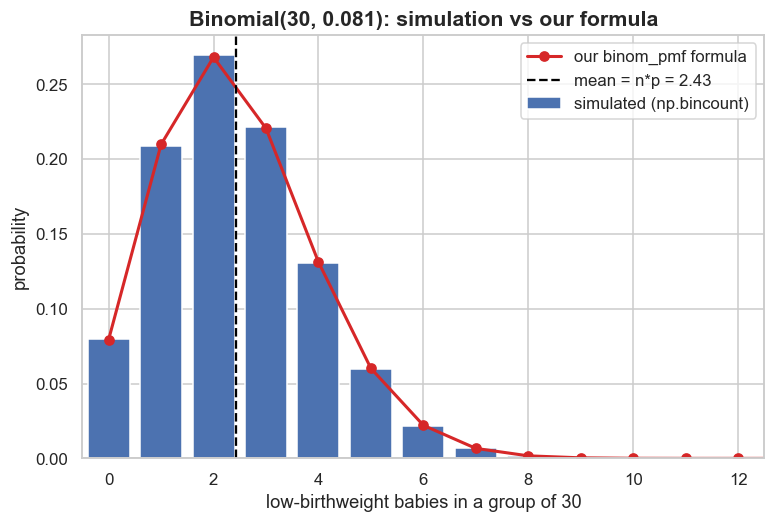

In [5]:
reps = 100_000
sims = rng.binomial(n, p, size=reps)                 # reps groups of 30, in one call

# np.bincount(sims)[k] = how many groups had exactly k successes.
emp_pmf = np.bincount(sims, minlength=n + 1) / reps  # divide by reps -> probabilities

print(f'simulated {reps:,} groups of {n} births')
print(f'simulated mean     = {sims.mean():.3f}   (theory n*p       = {n*p:.3f})')
print(f'simulated variance = {sims.var():.3f}   (theory n*p*(1-p) = {n*p*(1-p):.3f})')
print(f'\nP(exactly 2) — simulated {emp_pmf[2]:.4f}  vs formula {binom_pmf(2, n, p):.4f}')

fig, ax = plt.subplots()
ax.bar(ks, emp_pmf, color='#4c72b0', edgecolor='white', label='simulated (np.bincount)')
ax.plot(ks, mine, 'o-', color='#d62728', lw=2, label='our binom_pmf formula')
ax.axvline(n * p, color='black', ls='--', lw=1.5, label=f'mean = n*p = {n*p:.2f}')
ax.set_xlabel('low-birthweight babies in a group of 30')
ax.set_ylabel('probability')
ax.set_title(f'Binomial({n}, {p:.3f}): simulation vs our formula')
ax.set_xlim(-0.5, 12.5); ax.legend(); plt.show()

**Read it.** The red dots (our formula) sit right on the blue bars (the experiment), and our `binom_pmf`
matched SciPy exactly. The simulated mean and variance landed on $np$ and $np(1-p)$ — we never plugged those
formulas in; the simulation produced them.

### The Poisson pmf, straight from the formula

$$P(X=k) = \frac{\lambda^{k}\,e^{-\lambda}}{k!}, \qquad k = 0, 1, 2, \dots$$

Again one line: `lam**k * math.exp(-lam) / math.factorial(k)`. We write it, simulate daily quake counts with
`rng.poisson`, and check our formula against `stats.poisson.pmf` over the whole plausible range with
`np.allclose`.

lambda = 16.90 quakes/day
match? True
largest gap to scipy = 5.83e-16  (essentially zero)

simulated mean     = 16.90   (theory lambda   = 16.90)
simulated variance = 16.81   (theory lambda   = 16.90)


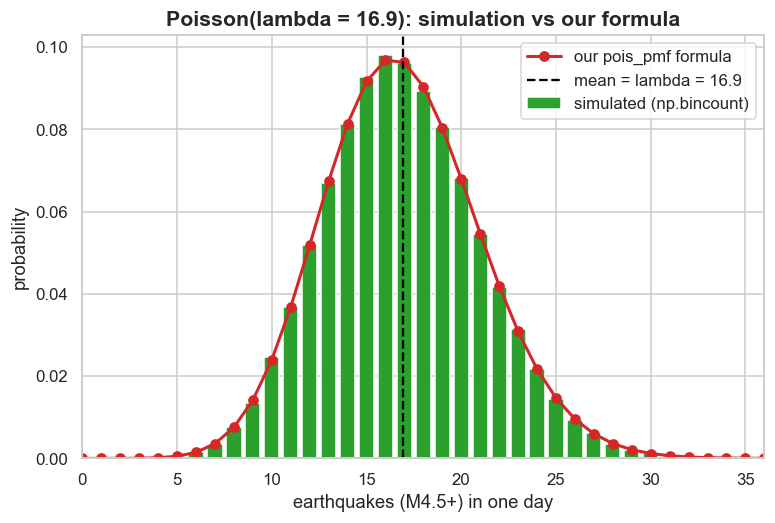

In [6]:
def pois_pmf(k, lam):
    '''Poisson probability of exactly k events when the rate is lam, from the formula.'''
    return lam**k * math.exp(-lam) / math.factorial(k)

ks_p     = np.arange(0, 40)
mine_p   = np.array([pois_pmf(int(k), lam) for k in ks_p])   # our formula
scipy_po = stats.poisson.pmf(ks_p, mu=lam)                   # the library

print(f'lambda = {lam:.2f} quakes/day')
print('match?', np.allclose(mine_p, scipy_po))
print(f'largest gap to scipy = {np.abs(mine_p - scipy_po).max():.2e}  (essentially zero)')

# Simulate daily counts and overlay our formula.
sims_p  = rng.poisson(lam, size=reps)
emp_p   = np.bincount(sims_p, minlength=len(ks_p))[:len(ks_p)] / reps
print(f'\nsimulated mean     = {sims_p.mean():.2f}   (theory lambda   = {lam:.2f})')
print(f'simulated variance = {sims_p.var():.2f}   (theory lambda   = {lam:.2f})')

fig, ax = plt.subplots()
ax.bar(ks_p, emp_p, color='#2ca02c', edgecolor='white', label='simulated (np.bincount)')
ax.plot(ks_p, mine_p, 'o-', color='#d62728', lw=2, label='our pois_pmf formula')
ax.axvline(lam, color='black', ls='--', lw=1.5, label=f'mean = lambda = {lam:.1f}')
ax.set_xlabel('earthquakes (M4.5+) in one day')
ax.set_ylabel('probability')
ax.set_title(f'Poisson(lambda = {lam:.1f}): simulation vs our formula')
ax.set_xlim(0, 36); ax.legend(); plt.show()

**Read it.** The Poisson fingerprint shows up twice: the *theory* mean equals the variance ($\lambda$), and
the *simulation* reproduces both. Our one-line `pois_pmf` matched SciPy across all 40 counts. Two formulas,
two functions, both verified against the library.

## 4) The idiom — vectorized simulation vs. a loop, and two ways to a pmf

### Why we let NumPy do the simulating

You *could* simulate the binomial with a Python `for` loop over the groups. It gives the same answer but is
slower and noisier to read. Compare the loop with the single vectorized `rng.binomial(...)` call.

In [7]:
import time

# The loop way (how you might first think of it): one group at a time.
t0 = time.perf_counter()
counts_loop = []
for _ in range(reps):
    group = rng.random(n) < p          # 30 yes/no draws
    counts_loop.append(int(group.sum()))
counts_loop = np.array(counts_loop)
t_loop = time.perf_counter() - t0

# The vectorized way (what the generator is for): all reps at once.
t0 = time.perf_counter()
counts_vec = rng.binomial(n, p, size=reps)
t_vec = time.perf_counter() - t0

print(f'loop result     : mean {counts_loop.mean():.3f}')
print(f'vectorized result: mean {counts_vec.mean():.3f}   <- same number, one line')
print(f'\nSimulating {reps:,} groups:')
print(f'  Python loop      : {t_loop*1000:8.1f} ms')
print(f'  rng.binomial(...): {t_vec*1000:8.1f} ms')
print(f'  vectorized is roughly {t_loop/max(t_vec,1e-9):.0f}x faster — and it is one short line.')

loop result     : mean 2.426
vectorized result: mean 2.420   <- same number, one line

Simulating 100,000 groups:
  Python loop      :    243.7 ms
  rng.binomial(...):      2.1 ms
  vectorized is roughly 118x faster — and it is one short line.


### Two ways to build the pmf *array* across a range of counts

We built our formula pmf with a **list comprehension**, `[binom_pmf(k, n, p) for k in ks]` — readable, one
`k` at a time. SciPy instead takes the whole array `ks` in **one vectorized call**, `stats.binom.pmf(ks, n,
p)`. Same numbers; the comprehension shows the formula, the vectorized call is the production idiom.

In [8]:
by_comprehension = np.array([binom_pmf(int(k), n, p) for k in ks])   # explicit, one k at a time
by_vectorized    = stats.binom.pmf(ks, n, p)                          # whole array at once

print('comprehension, first 5:', np.round(by_comprehension[:5], 4))
print('vectorized,    first 5:', np.round(by_vectorized[:5], 4))
print('same array?', np.allclose(by_comprehension, by_vectorized))
print("\nThe comprehension makes the formula visible; the vectorized call is what you reach for in code.")

comprehension, first 5: [0.0793 0.2098 0.2681 0.2205 0.1312]
vectorized,    first 5: [0.0793 0.2098 0.2681 0.2205 0.1312]
same array? True

The comprehension makes the formula visible; the vectorized call is what you reach for in code.


## 5) Refactor into a reusable function

Here the refactor is already done: **the two pmf functions you wrote in Section 3 *are* the reusable
artifacts.** Once validated against SciPy, you can call them anywhere — including to demonstrate the
Binomial→Poisson bridge with no new code at all.

The bridge: slice a day into a *huge* number $n$ of tiny instants, each a Bernoulli trial with a *tiny*
chance $p$, with the product $np = \lambda$ held fixed. As $n\to\infty$ and $p\to 0$, the Binomial pmf turns
into the Poisson pmf. We pick a large $n$ and small $p$ with $np = \lambda$ (our earthquake rate), then call
**our own** `binom_pmf` and `pois_pmf` across the counts and measure the largest gap.

n = 5000, p = 0.003380, so n*p = lambda = 16.90
largest |binom_pmf - pois_pmf| across all counts = 0.000164  (tiny -> they nearly coincide)


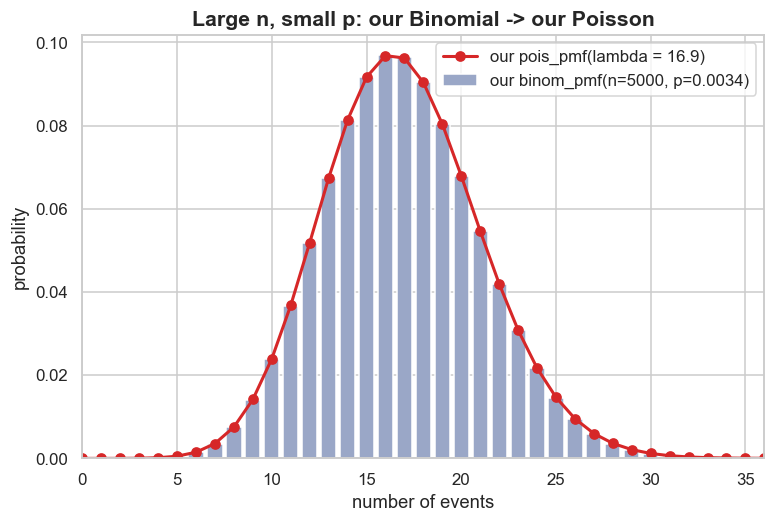

In [9]:
n_big   = 5000
p_small = lam / n_big           # so that n_big * p_small == lam exactly
lam_chk = n_big * p_small
ks_b    = np.arange(0, 40)

binom_side = np.array([binom_pmf(int(k), n_big, p_small) for k in ks_b])   # OUR binom_pmf
pois_side  = np.array([pois_pmf(int(k), lam_chk)          for k in ks_b])   # OUR pois_pmf

max_gap = np.abs(binom_side - pois_side).max()
print(f'n = {n_big}, p = {p_small:.6f}, so n*p = lambda = {lam_chk:.2f}')
print(f'largest |binom_pmf - pois_pmf| across all counts = {max_gap:.6f}  (tiny -> they nearly coincide)')

fig, ax = plt.subplots()
ax.bar(ks_b, binom_side, color='#9aa7c7', edgecolor='white',
       label=f'our binom_pmf(n={n_big}, p={p_small:.4f})')
ax.plot(ks_b, pois_side, 'o-', color='#d62728', lw=2,
        label=f'our pois_pmf(lambda = {lam_chk:.1f})')
ax.set_xlabel('number of events')
ax.set_ylabel('probability')
ax.set_title('Large n, small p: our Binomial -> our Poisson')
ax.set_xlim(0, 36); ax.legend(); plt.show()

A validated function is a contract: *give me a count (and the settings), I'll give you a probability.* Once
it's correct you stop re-deriving the formula and start *reusing* it — exactly the leap from "writing a
probability" to "doing probability in code." (And yes, `scipy.stats` exists; the point was to *build* the
pmf so you know what it is doing.)

## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — predict the answer
before you run it.

1. **A cdf from your pmf.** Write `binom_cdf(k, n, p)` that returns $P(X \le k)$ by summing your `binom_pmf`:
   `sum(binom_pmf(j, n, p) for j in range(k + 1))`. Test `binom_cdf(2, 30, p)` against `stats.binom.cdf(2,
   30, p)` — they should agree to many decimals.

2. **A tail probability ("5 or more").** Using `binom_pmf`, compute `P(X >= 5)` for the births model as
   `1 - sum(binom_pmf(k, 30, p) for k in range(5))`. Check it against `stats.binom.sf(4, 30, p)` (`sf` is the
   "survival function," $P(X > 4)$). Is a group of 30 with 5+ low-birthweight babies common or rare?

3. **Your Poisson pmf, every probability checked.** Build `mine = np.array([pois_pmf(k, lam) for k in
   range(0, 40)])` and `scipy_po = stats.poisson.pmf(np.arange(0, 40), mu=lam)`, then print
   `np.allclose(mine, scipy_po)` and the max absolute difference. Confirm `True` and a difference near `1e-16`.

4. **Push the bridge until it breaks.** In the Section-5 code, keep `n_big * p_small = lam` but make `p`
   *bigger* by shrinking `n_big` to `100` (so `p_small = lam / 100`). Re-run and read the new max gap: does
   the Binomial still hug the Poisson, or does the gap grow? What does that tell you about *how small* $p$
   must be for the shortcut to work?

## What you learned

**Coding**
- A **pmf is just a function**: `binom_pmf(k, n, p)` and `pois_pmf(k, lam)` each turn the math formula into
  one line, using `math.comb` / `math.factorial` / `math.exp`.
- **Check your code against a trusted library**: `np.allclose(mine, scipy)` is `True` only if every
  probability matches to floating-point precision — the from-scratch and SciPy pmfs agreed everywhere.
- **Vectorized simulation** (`rng.binomial(n, p, size=reps)`, `rng.poisson(lam, size=reps)`) replaces a
  per-group loop, reads cleaner, and runs far faster.
- **`np.bincount(sims) / reps`** turns a pile of simulated counts into an **empirical pmf** you can overlay
  on the formula.
- **Seed the generator** (`np.random.default_rng(0)`) so a notebook produces the same numbers every run.
- A validated function is **reusable**: the same two pmfs powered the Binomial→Poisson limit with no new code.

**Statistics (now demystified)**
- The Binomial pmf $\binom{n}{k}p^k(1-p)^{n-k}$ and the Poisson pmf $e^{-\lambda}\lambda^k/k!$ are each just a
  short formula; you reproduced every SciPy probability to the decimal.
- $p$ is a **proportion** (the mean of a True/False column); $\lambda$ is an **average count per interval**.
- The Binomial's mean/variance are $np$ and $np(1-p)$; the Poisson's mean and variance are both $\lambda$ —
  your simulations reproduced all of them.
- **Binomial → Poisson** as $n\to\infty$, $p\to 0$ with $np = \lambda$: the two count models are one idea,
  and you watched your own functions nearly coincide.

**Back to the core lesson** ([Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb)) for the
*meaning* of these models, or read on through the course.

---

**↩ Back to the lesson:** [Lesson 8: Binomial & Poisson — counting events](08-binomial-poisson.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](08-binomial-poisson~another-dataset.ipynb)